<a href="https://colab.research.google.com/github/BrisseidaEsmeraldaGonzalezCabriales/Modelado-y-simulaci-n-de-sistemas-mecatronicos-/blob/main/PIA_MODELADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRODUCTO INTEGRADOR DE APRENDIZAJE (PIA)

Modelado y Simulación de Sistemas Mecatrónicos

Brsseida Esmeralda Gonzalez Cabriales 1974257

Ana Camila Parra Aguilar 2052187

Jesus Roman Aguirre Hernsndez 2053240

Jair Eduardo Benavides Garcia 2052989

In [1]:
import numpy as np

# Robot de transmisión directa de 2GDL
def cap5_robot2gdl(t, x):
    # vector de posición articular
    q = np.array([x[0], x[1]])
    # vector de velocidad articular
    qp = np.array([x[2], x[3]])

    # Modelo dinámico del robot
    # matriz de inercia
    M = np.array([[3.117 + 0.2 * np.cos(q[1]), 0.108 + 0.1 * np.cos(q[1])],
                  [0.108 + 0.1 * np.cos(q[1]), 0.108]])

    # Matriz de fuerzas centrípetas y de coriolis
    C = np.array([[-0.2 * np.sin(q[1]) * qp[1], -0.1 * np.sin(q[1]) * qp[1]],
                  [0.1 * np.sin(q[1]) * qp[0], 0.0]])

    # Vector de pares de gravitacionales
    par_grav = np.array([[39.3 * np.sin(q[0]) + 1.95 * np.sin(q[0] + q[1])],
                         [1.95 * np.sin(q[0] + q[1])]])

    # vector de pares de fricción viscosa
    # np.sign handles scalar and array inputs
    fr = np.array([[1.86 * qp[0] + 1.93 * np.sign(qp[0])],
                   [0.16 * qp[1] + 0.3 * np.sign(qp[1])]])

    tau = np.array([[(1 - np.exp(-0.8 * t)) * 32.0 + 56 * np.sin(16 * t + 0.1) + 12 * np.sin(20 * t + 0.15)],
                    [(1 - np.exp(-1.8 * t)) * 1.2 + 8 * np.sin(26 * t + 0.08) + 2 * np.sin(12 * t + 0.34)]])

    # vector de aceleración articular
    # Use np.linalg.solve for more numerical stability than inv(M) @ ...
    q2p = np.linalg.solve(M, (tau - C @ qp[:, np.newaxis] - par_grav - fr))

    # vector de salida
    xp = np.array([qp[0], qp[1], q2p[0,0], q2p[1,0]])
    return xp

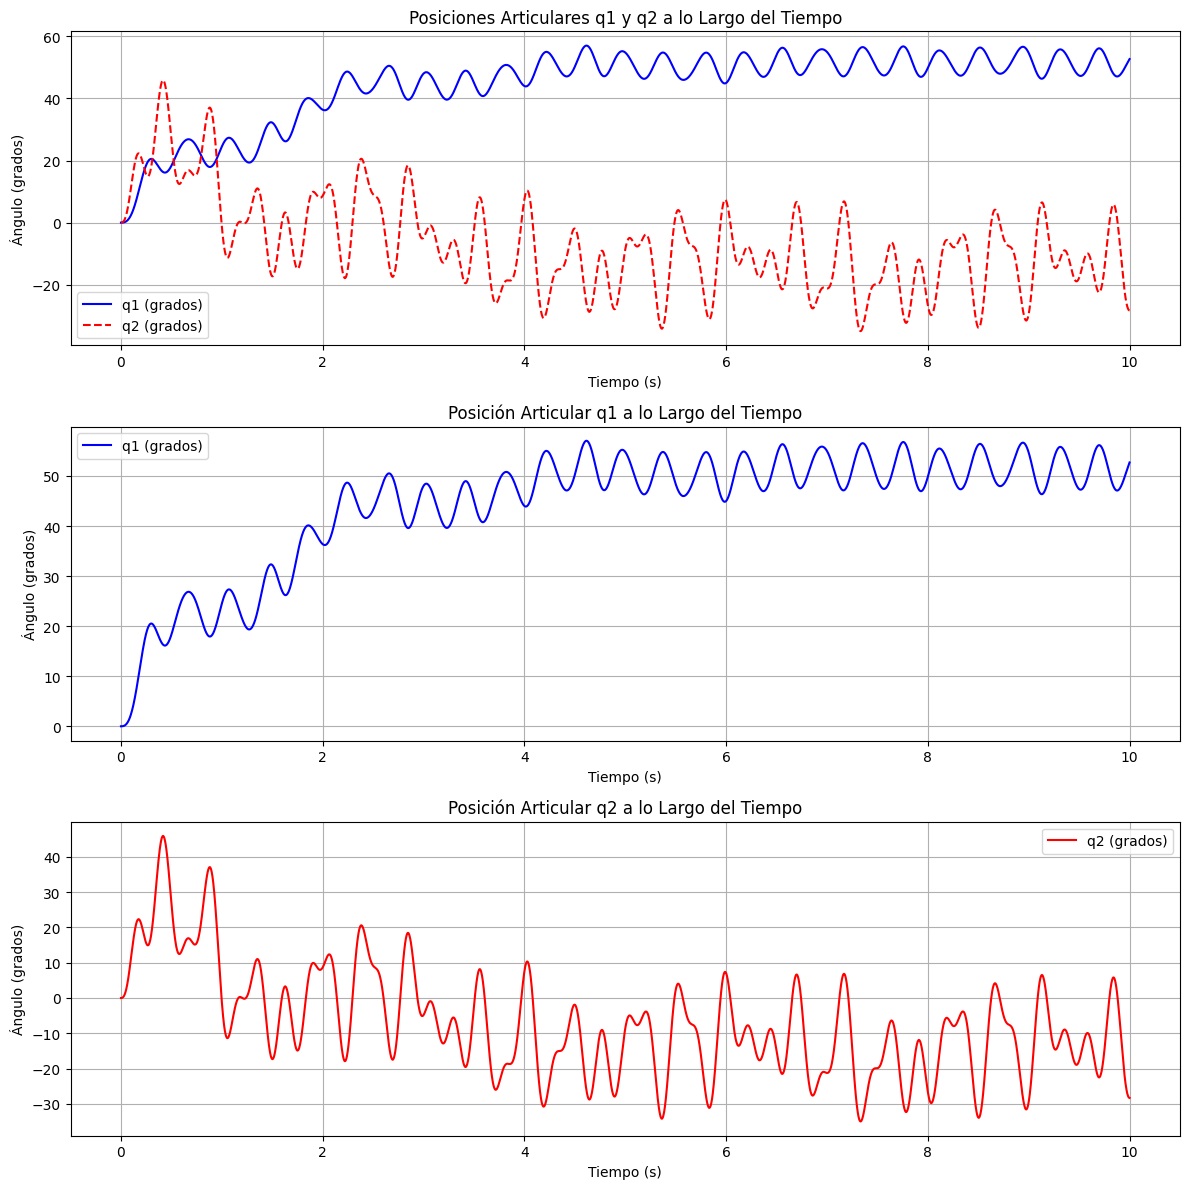

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# parámetros de simulación:
ti = 0  # tiempo inicial
h = 0.0025  # incremento del tiempo
tf = 10  # tiempo final de simulación
ts = np.arange(ti, tf + h, h)  # tiempo de simulación

# Initial conditions
x0 = np.array([0, 0, 0, 0])

# Solve the ODE using solve_ivp (equivalent to ode45)
sol = solve_ivp(cap5_robot2gdl, (ti, tf), x0, t_eval=ts, rtol=1e-3, max_step=2.5e-3)

t = sol.t
x = sol.y.T # Transpose y to get columns as variables, rows as time points

# Plotting (equivalent to plot)
# Creating three subplots:
# 1. q1 and q2 together
# 2. q1 alone
# 3. q2 alone
plt.figure(figsize=(12, 12))

# Subplot 1: q1 and q2 together
plt.subplot(3, 1, 1) # 3 rows, 1 column, first plot
plt.plot(t, (180 / np.pi) * x[:, 0], label='q1 (grados)', color='blue')
plt.plot(t, (180 / np.pi) * x[:, 1], label='q2 (grados)', color='red', linestyle='--')
plt.xlabel('Tiempo (s)')
plt.ylabel('Ángulo (grados)')
plt.title('Posiciones Articulares q1 y q2 a lo Largo del Tiempo')
plt.legend()
plt.grid(True)

# Subplot 2: q1 alone
plt.subplot(3, 1, 2) # 3 rows, 1 column, second plot
plt.plot(t, (180 / np.pi) * x[:, 0], label='q1 (grados)', color='blue')
plt.xlabel('Tiempo (s)')
plt.ylabel('Ángulo (grados)')
plt.title('Posición Articular q1 a lo Largo del Tiempo')
plt.legend()
plt.grid(True)

# Subplot 3: q2 alone
plt.subplot(3, 1, 3) # 3 rows, 1 column, third plot
plt.plot(t, (180 / np.pi) * x[:, 1], label='q2 (grados)', color='red')
plt.xlabel('Tiempo (s)')
plt.ylabel('Ángulo (grados)')
plt.title('Posición Articular q2 a lo Largo del Tiempo')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show()